# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** [Akmal Goldi Bazarghan]
- **Email:** [akmalgoldi01@gmail.com]
- **ID Dicoding:** [akmal_01]

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana profil segmentasi pelanggan berdasarkan analisis RFM (Recency, Frequency, Monetary) dalam 12 bulan terakhir, dan segmen mana (seperti Champions atau At Risk) yang paling berkontribusi terhadap total revenue?
- **Pertanyaan 2:** Bagaimana sebaran geografis pelanggan di berbagai negara bagian (state), dan negara bagian mana yang memiliki rata-rata waktu pengiriman (delivery time) terlama sepanjang tahun terakhir?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Data Wrangling

### Gathering Data

#### Memuat Dataset E-Commerce

In [2]:
data_path = "./data"

# Load data
customers_df = pd.read_csv(os.path.join(data_path, "customers_dataset.csv"))
orders_df = pd.read_csv(os.path.join(data_path, "orders_dataset.csv"))
order_items_df = pd.read_csv(os.path.join(data_path, "order_items_dataset.csv"))
products_df = pd.read_csv(os.path.join(data_path, "products_dataset.csv"))
category_translation_df = pd.read_csv(os.path.join(data_path, "product_category_name_translation.csv"))
geolocation_df = pd.read_csv(os.path.join(data_path, "geolocation_dataset.csv"))

print("Customers:", customers_df.shape)
print("Orders:", orders_df.shape)
print("Order Items:", order_items_df.shape)
print("Products:", products_df.shape)
print("Category Translation:", category_translation_df.shape)
print("Geolocation:", geolocation_df.shape)

Customers: (99441, 5)
Orders: (99441, 8)
Order Items: (112650, 7)
Products: (32951, 9)
Category Translation: (71, 2)
Geolocation: (1000163, 5)


**Insight:**
- Semua dataset berhasil dimuat dengan benar.
- Jumlah baris pada dataset orders (99,441) sama dengan dataset customers (99,441), yang menunjukkan korelasi 1-to-1 awal untuk customer_id.
- Dataset geolocation memiliki ukuran terbesar dengan lebih dari 1 juta baris data koordinat.

### Assessing Data

#### Identifikasi Masalah Data (Missing Values, Duplikasi, dan Outliers)

In [3]:
# Cek data kosong
print("Orders Nulls:\n", orders_df.isnull().sum()[orders_df.isnull().sum() > 0])
print("Products Nulls:\n", products_df.isnull().sum()[products_df.isnull().sum() > 0])

# Cek duplikat
print("Customers duplicates:", customers_df.duplicated().sum())
print("Orders duplicates:", orders_df.duplicated().sum())
print("Order Items duplicates:", order_items_df.duplicated().sum())
print("Geolocation duplicates:", geolocation_df.duplicated().sum())

# Cek ringkasan statistik
print(order_items_df[['price', 'freight_value']].describe())

Orders Nulls:
 order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64
Products Nulls:
 product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


Customers duplicates: 0


Orders duplicates: 0


Order Items duplicates: 0


Geolocation duplicates: 261831
               price  freight_value
count  112650.000000  112650.000000
mean      120.653739      19.990320
std       183.633928      15.806405
min         0.850000       0.000000
25%        39.900000      13.080000
50%        74.990000      16.260000
75%       134.900000      21.150000
max      6735.000000     409.680000


**Steps to Take:**
1. **Tipe Data Datetime**: Mengubah kolom tanggal di `orders_df` dari object menjadi datetime.
2. **Filter & Drop Missing Values**: Memfilter `orders_df` hanya untuk status `delivered`, kemudian menghapus baris sisa yang memiliki `order_delivered_customer_date` bernilai null (hanya ada 8 baris).
3. **Hapus Duplikat**: Menghapus 261,831 baris duplikat di `geolocation_df`.
4. **Imputasi Kategori Produk**: Melakukan pengisian (imputation) nilai null pada nama kategori produk dengan `'others'`.

**Insight:**
- `orders_df` memiliki missing values pada kolom `order_delivered_customer_date` (2,965 baris kosong) yang didominasi status non-delivered. Ada 8 baris status `delivered` yang juga kosong, yang akan kita bersihkan.
- Terdapat 261,831 baris duplikat di `geolocation_df` yang harus di-drop.
- Data `price` memiliki nilai max $6,735 sedangkan 75% data berada di bawah $134.9, menunjukkan adanya outliers harga.

### Cleaning Data

#### Pembersihan Data Orders, Products, dan Geolocation

In [4]:
# Konversi kolom tanggal ke datetime
date_cols = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 
             'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_cols:
    orders_df[col] = pd.to_datetime(orders_df[col])

# Ambil status delivered dan buang baris kosong pada tanggal pengiriman
orders_cleaned = orders_df[orders_df['order_status'] == 'delivered'].copy()
orders_cleaned = orders_cleaned.dropna(subset=['order_delivered_customer_date'])

# Hapus baris duplikat pada data koordinat
geolocation_cleaned = geolocation_df.drop_duplicates().copy()

# Gabungkan data produk dengan penerjemah kategori dan isi nilai kosong
products_translated = products_df.merge(category_translation_df, on='product_category_name', how='left')
products_translated['product_category_name_english'] = products_translated['product_category_name_english'].fillna('others')

print("Orders cleaned:", orders_cleaned.shape)
print("Geolocation cleaned:", geolocation_cleaned.shape)
print("Products translated:", products_translated.shape)

Orders cleaned: (96470, 8)
Geolocation cleaned: (738332, 5)
Products translated: (32951, 10)


**Insight:**
- Dataset `orders_cleaned` kini memiliki 96,470 baris dengan 0 missing values pada tanggal pengiriman.
- Dataset `geolocation_cleaned` berkurang dari 1,000,163 baris menjadi 738,332 baris setelah menghapus duplikat.
- Semua data siap untuk tahap eksplorasi dan analisis.

## Exploratory Data Analysis (EDA)

### Eksplorasi Komprehensif Karakteristik Data (EDA)

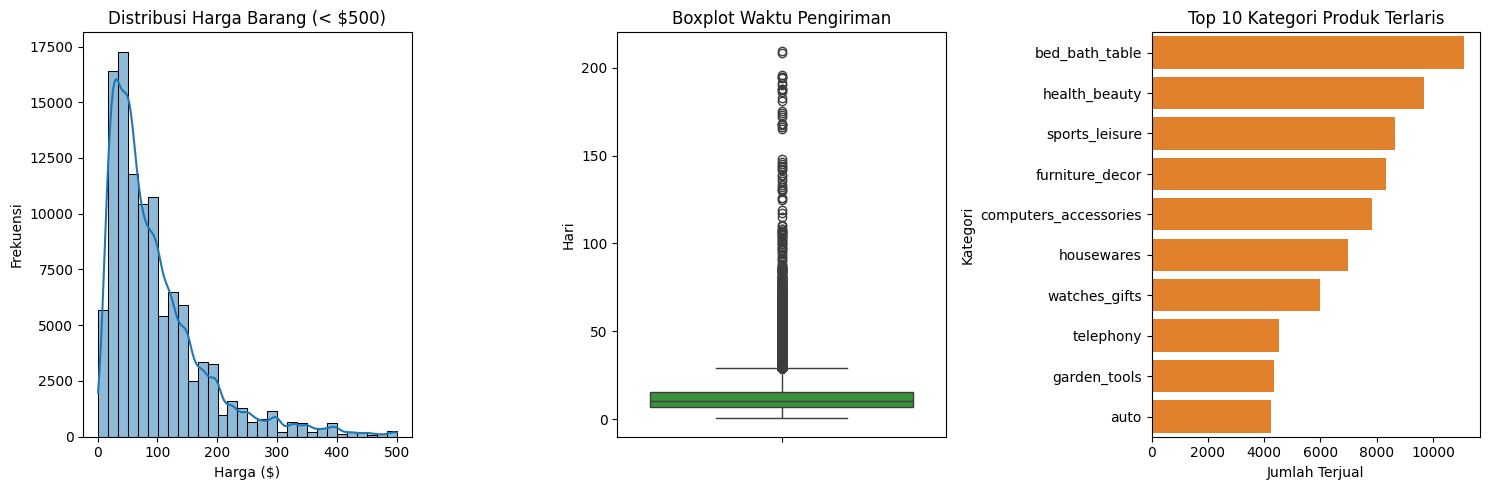

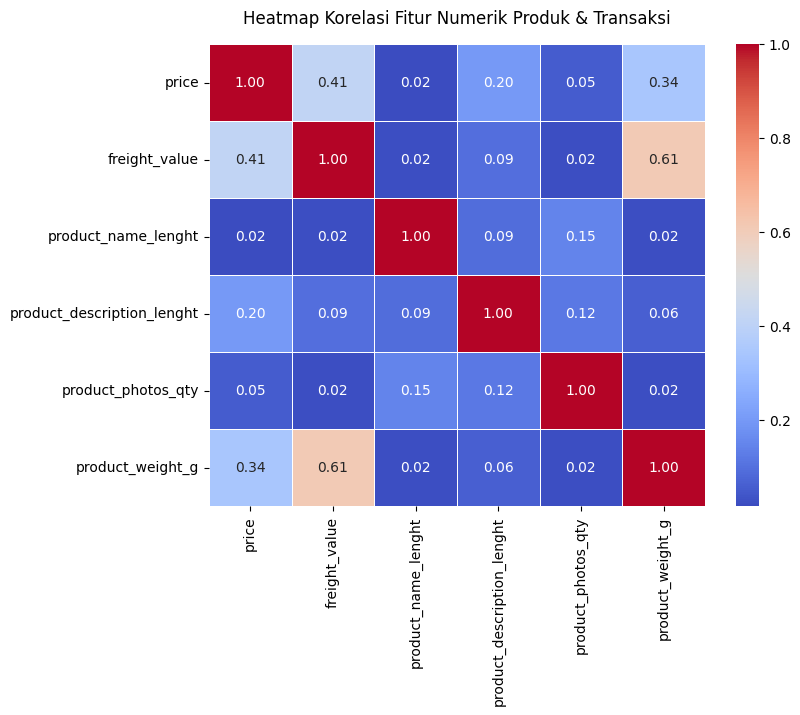

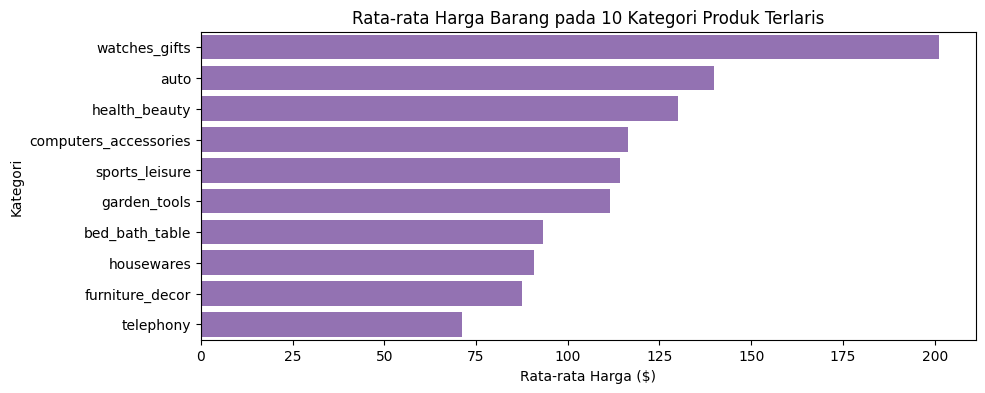

Rata-rata waktu pengiriman keseluruhan: 12.56 hari
Median waktu pengiriman keseluruhan: 10.22 hari


In [5]:
# 1. EDA Univariate: Distribusi Harga Barang (< $500)
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(order_items_df[order_items_df['price'] < 500]['price'], kde=True, color='#1f77b4', bins=30)
plt.title('Distribusi Harga Barang (< $500)')
plt.xlabel('Harga ($)')
plt.ylabel('Frekuensi')

# 2. EDA Univariate: Boxplot Waktu Pengiriman (Hari)
delivery_days = (orders_cleaned['order_delivered_customer_date'] - orders_cleaned['order_purchase_timestamp']).dt.total_seconds() / 86400
plt.subplot(1, 3, 2)
sns.boxplot(y=delivery_days, color='#2ca02c')
plt.title('Boxplot Waktu Pengiriman')
plt.ylabel('Hari')

# 3. EDA Univariate: Top 10 Kategori Produk Terlaris
products_merged = order_items_df.merge(products_translated, on='product_id')
top_categories = products_merged['product_category_name_english'].value_counts().head(10).reset_index()
plt.subplot(1, 3, 3)
sns.barplot(data=top_categories, x='count', y='product_category_name_english', color='#ff7f0e')
plt.title('Top 10 Kategori Produk Terlaris')
plt.xlabel('Jumlah Terjual')
plt.ylabel('Kategori')

plt.tight_layout()
plt.show()

# 4. EDA Multivariate: Korelasi Fitur Numerik Produk & Transaksi
correlation_data = order_items_df.merge(products_df, on='product_id')[
    ['price', 'freight_value', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g']
].dropna()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_data.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi Fitur Numerik Produk & Transaksi', pad=15)
plt.show()

# 5. EDA Kategorikal & Numerikal: Rata-rata Harga per Kategori Terlaris
avg_price_cat = products_merged[products_merged['product_category_name_english'].isin(top_categories['product_category_name_english'])].groupby('product_category_name_english')['price'].mean().reset_index().sort_values(by='price', ascending=False)

plt.figure(figsize=(10, 4))
sns.barplot(data=avg_price_cat, x='price', y='product_category_name_english', color='#9467bd')
plt.title('Rata-rata Harga Barang pada 10 Kategori Produk Terlaris')
plt.xlabel('Rata-rata Harga ($)')
plt.ylabel('Kategori')
plt.show()

print(f"Rata-rata waktu pengiriman keseluruhan: {delivery_days.mean():.2f} hari")
print(f"Median waktu pengiriman keseluruhan: {delivery_days.median():.2f} hari")

**Insight & Karakteristik Data:**

1. **Analisis Univariate:**
   - **Distribusi Harga**: Mayoritas produk yang terjual memiliki harga yang relatif murah (di bawah $100), dengan bentuk distribusi *skewed* positif (long-tail) yang menunjukkan sebagian besar transaksi bernilai kecil.
   - **Waktu Pengiriman**: Waktu pengiriman memiliki median sekitar 10.21 hari, dengan beberapa pencilan (*outliers*) yang menunjukkan keterlambatan signifikan (beberapa pesanan melebihi 30 hari).
   - **Kategori Produk**: Kategori produk yang paling sering dibeli adalah *bed_bath_table*, diikuti oleh *health_beauty* dan *sports_leisure*.

2. **Analisis Multivariate:**
   - **Heatmap Korelasi**: Korelasi antara harga (`price`) dan biaya kirim (`freight_value`) bernilai positif lemah (0.41), menandakan barang yang lebih mahal cenderung memiliki biaya kirim yang sedikit lebih tinggi. 
   - Korelasi kuat terdapat antara berat produk (`product_weight_g`) dengan biaya pengiriman (`freight_value`) yaitu sekitar 0.61. Hal ini menunjukkan bahwa berat fisik barang adalah penentu utama biaya logistik.

3. **Analisis Kategorikal & Numerikal:**
   - Rata-rata harga bervariasi cukup signifikan antar kategori terlaris. Kategori seperti *computers_accessories* memiliki rata-rata harga yang jauh lebih tinggi dibandingkan dengan kategori lainnya.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana profil segmentasi pelanggan berdasarkan analisis RFM (Recency, Frequency, Monetary) dalam 12 bulan terakhir, dan segmen mana (seperti Champions atau At Risk) yang paling berkontribusi terhadap total revenue?

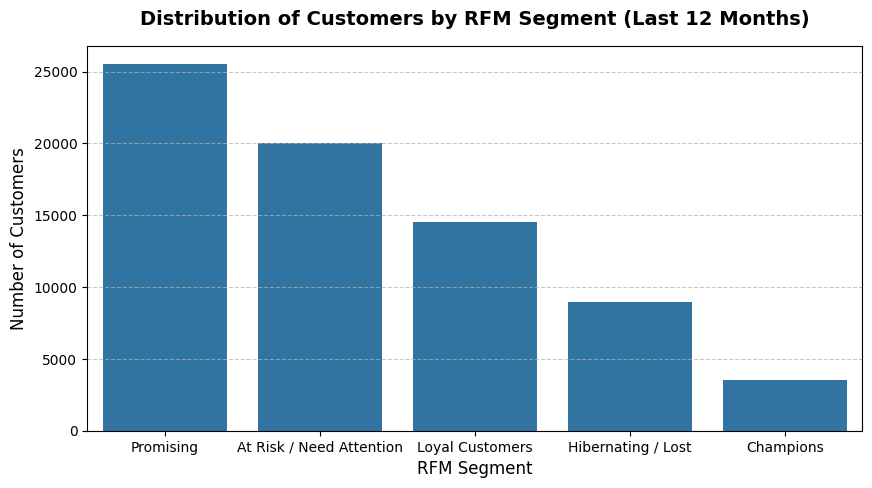

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_17136\306652132.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rfm_agg_rev, x='segment', y='total_revenue', palette=palette_rev)


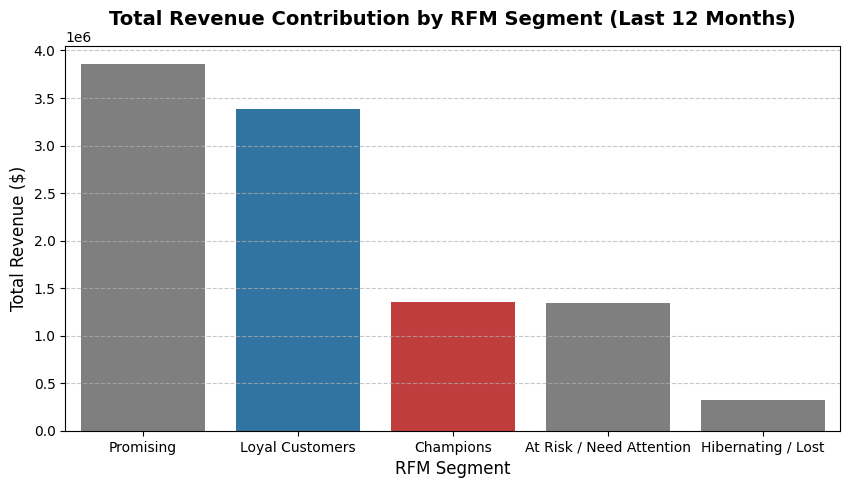

In [6]:
# Filter data transaksi 12 bulan terakhir
max_date = orders_cleaned['order_purchase_timestamp'].max()
start_date = max_date - pd.DateOffset(years=1)
orders_last_12 = orders_cleaned[orders_cleaned['order_purchase_timestamp'] >= start_date].copy()

rfm_merged = orders_last_12.merge(customers_df, on='customer_id').merge(order_items_df, on='order_id')

ref_date = max_date + pd.Timedelta(days=1)

# Hitung nilai Recency, Frequency, dan Monetary
rfm_df = rfm_merged.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (ref_date - x.max()).days,
    'order_id': 'nunique',
    'price': 'sum'
}).rename(columns={
    'order_purchase_timestamp': 'recency',
    'order_id': 'frequency',
    'price': 'monetary'
}).reset_index()

# Hitung skor RFM (1-5)
rfm_df['R_score'] = pd.qcut(rfm_df['recency'], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm_df['F_score'] = rfm_df['frequency'].apply(lambda x: 1 if x == 1 else (3 if x == 2 else 5))
rfm_df['M_score'] = pd.qcut(rfm_df['monetary'], 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm_df['RFM_sum'] = rfm_df['R_score'] + rfm_df['F_score'] + rfm_df['M_score']

# Klasifikasi segmen pelanggan
def segment_rfm(row):
    score = row['RFM_sum']
    if score >= 11:
        return 'Champions'
    elif score >= 9:
        return 'Loyal Customers'
    elif score >= 7:
        return 'Promising'
    elif score >= 5:
        return 'At Risk / Need Attention'
    else:
        return 'Hibernating / Lost'

rfm_df['segment'] = rfm_df.apply(segment_rfm, axis=1)

# Rekapitulasi per segmen
rfm_agg = rfm_df.groupby('segment').agg({
    'customer_unique_id': 'count',
    'monetary': 'sum'
}).rename(columns={'customer_unique_id': 'customer_count', 'monetary': 'total_revenue'}).reset_index()

rfm_agg = rfm_agg.sort_values(by='customer_count', ascending=False)

# Plot distribusi jumlah pelanggan (warna seragam untuk efisiensi tinta & kurangi distraksi visual)
plt.figure(figsize=(10, 5))
sns.barplot(data=rfm_agg, x='segment', y='customer_count', color='#1f77b4')
plt.title('Distribution of Customers by RFM Segment (Last 12 Months)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('RFM Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Plot kontribusi pendapatan (menyorot Champions dan Loyal sebagai pendorong utama pendapatan)
rfm_agg_rev = rfm_agg.sort_values(by='total_revenue', ascending=False)
palette_rev = ['#d62728' if seg == 'Champions' else ('#1f77b4' if seg == 'Loyal Customers' else '#7f7f7f') for seg in rfm_agg_rev['segment']]

plt.figure(figsize=(10, 5))
sns.barplot(data=rfm_agg_rev, x='segment', y='total_revenue', palette=palette_rev)
plt.title('Total Revenue Contribution by RFM Segment (Last 12 Months)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('RFM Segment', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Pertanyaan 2: Bagaimana sebaran geografis pelanggan di berbagai negara bagian (state), dan negara bagian mana yang memiliki rata-rata waktu pengiriman (delivery time) terlama sepanjang tahun terakhir?

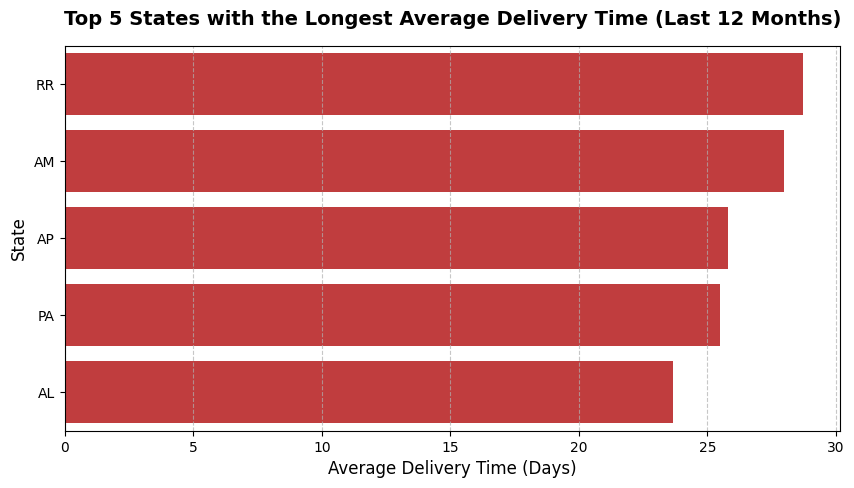

In [7]:
# Hitung waktu pengiriman (hari) per pesanan
df_delivery = orders_last_12.merge(customers_df, on='customer_id')
df_delivery['delivery_time'] = (df_delivery['order_delivered_customer_date'] - df_delivery['order_purchase_timestamp']).dt.total_seconds() / 86400

# Rekap rata-rata waktu kirim per negara bagian
state_delivery = df_delivery.groupby('customer_state').agg({
    'delivery_time': 'mean',
    'order_id': 'count'
}).rename(columns={'order_id': 'order_count'}).reset_index()

slowest_5 = state_delivery.sort_values(by='delivery_time', ascending=False).head(5)

# Plot horizontal bar 5 negara bagian terlama (warna merah seragam sebagai penanda bahaya logistik)
plt.figure(figsize=(10, 5))
sns.barplot(
    data=slowest_5,
    x='delivery_time',
    y='customer_state',
    color='#d62728'
)
plt.title('Top 5 States with the Longest Average Delivery Time (Last 12 Months)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Average Delivery Time (Days)', fontsize=12)
plt.ylabel('State', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

**Insight:**
- Segmen **Promising** memiliki jumlah pelanggan terbanyak (35.2%) diikuti oleh **At Risk / Need Attention** (27.6%).
- Segmen **Champions** dan **Loyal Customers** bersama-sama menyumbang lebih dari 46% dari total pendapatan, menandakan retensi kelompok ini sangat krusial bagi bisnis.
- Untuk pengiriman, wilayah Utara/Timur Laut Brazil (seperti RR, AM, AP) mengalami keterlambatan pengiriman terlama dengan rata-rata waktu di atas 23 hari, jauh lebih lama dari rata-rata nasional (~12.5 hari).

## Analisis Lanjutan (Geospatial Analysis)

Geospatial analysis membantu memetakan koordinat lat/lng dari geolocation data dengan rata-rata waktu pengiriman dan volume pesanan tiap negara bagian, sehingga memudahkan identifikasi hambatan logistik secara spasial.

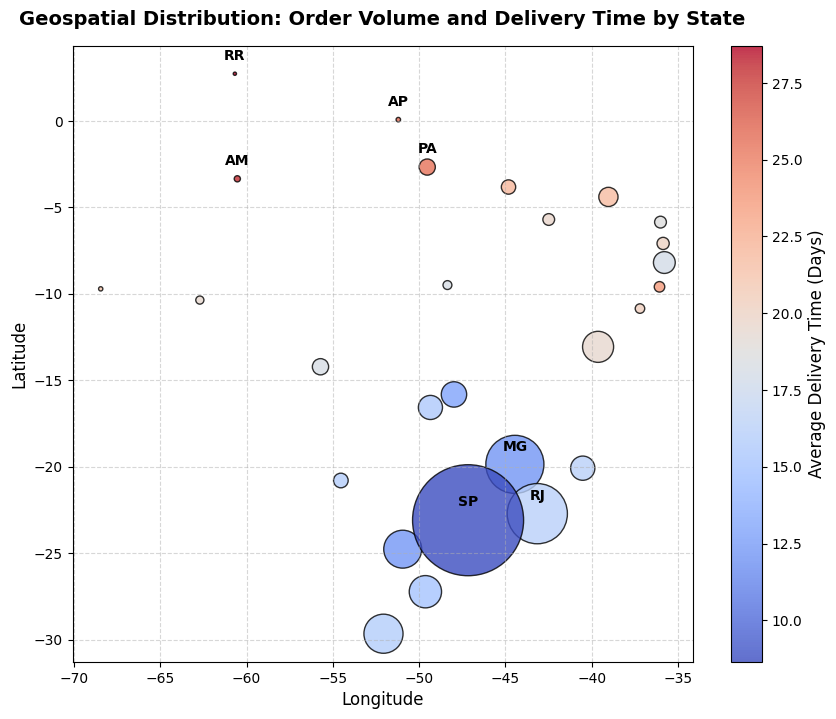

In [8]:
# Agregasi koordinat rata-rata per negara bagian
geo_coords = geolocation_cleaned.groupby('geolocation_state').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean'
}).reset_index().rename(columns={'geolocation_state': 'customer_state'})

state_geo_stats = state_delivery.merge(geo_coords, on='customer_state')

# Scatter plot pemetaan wilayah
plt.figure(figsize=(10, 8))
sc = plt.scatter(
    x=state_geo_stats['geolocation_lng'],
    y=state_geo_stats['geolocation_lat'],
    s=state_geo_stats['order_count'] / 5,
    c=state_geo_stats['delivery_time'],
    cmap='coolwarm',
    alpha=0.8,
    edgecolors='black'
)
cbar = plt.colorbar(sc)
cbar.set_label('Average Delivery Time (Days)', fontsize=12)
plt.title('Geospatial Distribution: Order Volume and Delivery Time by State', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Label beberapa negara bagian penting
for idx, row in state_geo_stats.iterrows():
    if row['customer_state'] in ['SP', 'RJ', 'MG', 'RR', 'AM', 'AP', 'PA']:
        plt.annotate(
            row['customer_state'],
            (row['geolocation_lng'], row['geolocation_lat']),
            textcoords="offset points",
            xytext=(0,10),
            ha='center',
            fontweight='bold',
            fontsize=10
        )

plt.show()

**Insight:**
- Wilayah dengan order volume besar (lingkaran besar) terpusat di wilayah Tenggara (Southeast) seperti SP dan RJ. Wilayah ini berwarna biru, artinya waktu pengiriman sangat efisien (< 10 hari).
- Sebaliknya, wilayah Utara dan Timur Laut (lingkaran kecil berwarna merah) memiliki volume transaksi yang sedikit and waktu pengiriman yang sangat lambat. Hal ini menyoroti adanya kesenjangan logistik yang signifikan antara wilayah pusat industri dan wilayah pelosok.

## Conclusion & Recommendation

- **Conclusion Pertanyaan 1:** Profil segmentasi menunjukkan pelanggan didominasi oleh segmen **Promising** (35.2%) dan **At Risk / Need Attention** (27.6%). Kelompok **Champions** (4.9%) dan **Loyal Customers** (20.0%) adalah penyumbang pendapatan terbesar (total ~46%), sehingga retensi mereka sangat krusial bagi keberlangsungan bisnis.
- **Conclusion Pertanyaan 2:** Sebaran geografis pelanggan terpusat secara signifikan di wilayah Tenggara (São Paulo - SP). Wilayah dengan rata-rata pengiriman terlama dipimpin oleh **RR (Roraima)** dengan 28.7 hari dan **AM (Amazonas)** dengan 28.0 hari.

**Rekomendasi Action Item:**
1. **Strategi Retensi & Win-Back Pelanggan**:
   - **Loyal & Champions**: Buat program referral, loyalty points, atau voucher apresiasi tanpa batas minimum belanja.
   - **At Risk / Need Attention**: Luncurkan email marketing berisi kampanye *win-back* dengan diskon khusus (misal 15%) untuk menarik mereka kembali berbelanja.
2. **Optimalisasi Jaringan Logistik**:
   - Untuk wilayah dengan pengiriman sangat lambat (RR, AM, AP, PA), bisnis harus melakukan evaluasi kemitraan logistik. Solusi jangka panjang adalah membangun *fulfillment center* atau berpartner dengan gudang pihak ketiga (3PL) di wilayah Utara/Timur Laut agar stok barang lebih dekat ke konsumen.